# CEG3004:DSP Mini-Project: Environmental Sound Classification

**You will improve the DSP feature pipeline and the ML model.**

✅ Train on: `data/train` (labeled)  
✅ Predict on: `data/submission` (unlabeled; includes `__clean`, `__noisy`, `__bandlimited`)  
✅ Submit: 1) The model in `<GROUP_ID>_model.joblib` and 2) `<GROUP_ID>_predictions.csv` to xsite Dropbox

---

## Student TODO Map (what you should improve)

1. **Preprocessing** (normalization, trimming/padding, filtering etc)
2. **Feature extraction** (MFCC/log-mel/spectral features, CMVN, deltas, pooling)
3. **Modeling** (classifier choice + hyperparameters)
4. **Robustness** (augmentation ideas: noise, random bandpass, gain)

All places you should edit are marked as:

> **🟨 STUDENT TODO**


In [ ]:
#@title Enter Your Project Group Number
#@markdown This should be as per xcite Group (e.g. Pr_1)
GROUP_ID = "Pr_18" #@param {type:"string"}

if not GROUP_ID:
  raise ValueError("You must enter a Group ID to proceed. Please run this cell again.")

print(f"Welcome Group, {GROUP_ID}!")

Welcome Group, Pr_18!


In [ ]:
#@title 1) Setup (install deps)
!pip -q install numpy scipy pandas scikit-learn librosa soundfile tqdm


In [ ]:
#@title 2) Download dataset ZIP from Google Drive
!pip -q install gdown

import gdown
import zipfile
import os

FILE_ID = "1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj"
zip_path = "CEG3004_Project_Data.zip"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", zip_path, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj
From (redirected): https://drive.google.com/uc?id=1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj&confirm=t&uuid=d795706b-6922-4ab8-9214-0929cb6e706d
To: /content/CEG3004_Project_Data.zip
100%|██████████| 787M/787M [00:15<00:00, 51.2MB/s]


'CEG3004_Project_Data.zip'

In case the above code fails due to overload, you can manually download the data from the link [here](https://drive.google.com/file/d/1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj/view?usp=sharing) and upload to colab using folder icon on the left panel. Please see the picture below


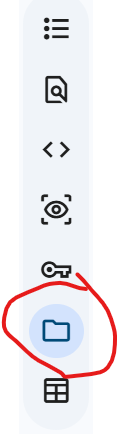

In [ ]:
#Extract the folder
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content")

print("Dataset extracted.")

Dataset extracted.


In [ ]:
#@title 3) Set paths (EDIT ME IF REQUIRED)
import os

# 🟨 STUDENT TODO: Set this to your Drive path
# Example: '/content/drive/MyDrive/data'
DATA_ROOT = "/content/"

TRAIN_DIR = os.path.join(DATA_ROOT, 'data', 'train')
SUBMISSION_DIR = os.path.join(DATA_ROOT, 'data', 'submission')

print('TRAIN_DIR:', TRAIN_DIR)
print('SUBMISSION_DIR:', SUBMISSION_DIR)
assert os.path.exists(TRAIN_DIR), 'Train directory not found'
assert os.path.exists(SUBMISSION_DIR), 'Submission directory not found'


TRAIN_DIR: /content/data/train
SUBMISSION_DIR: /content/data/submission


In [ ]:
#@title 🔍 Dataset Safety Check (DO NOT MODIFY)

import os
import pandas as pd

print("Checking dataset structure...\n")

train_dir = os.path.join(DATA_ROOT, "data", "train")
submission_dir = os.path.join(DATA_ROOT, "data", "submission")

assert os.path.exists(train_dir), "❌ Missing data/train folder"
assert os.path.exists(submission_dir), "❌ Missing data/submission folder"

labels_path = os.path.join(train_dir, "labels.csv")
meta_path = os.path.join(submission_dir, "metadata.csv")

assert os.path.exists(labels_path), "❌ Missing labels.csv in train"
assert os.path.exists(meta_path), "❌ Missing metadata.csv in submission"

train_audio_dir = os.path.join(train_dir, "audio")
sub_audio_dir = os.path.join(submission_dir, "audio")

assert os.path.exists(train_audio_dir), "❌ Missing train/audio folder"
assert os.path.exists(sub_audio_dir), "❌ Missing submission/audio folder"

train_wavs = [f for f in os.listdir(train_audio_dir) if f.endswith(".wav")]
sub_wavs = [f for f in os.listdir(sub_audio_dir) if f.endswith(".wav")]

assert len(train_wavs) > 0, "❌ No training WAV files found"
assert len(sub_wavs) > 0, "❌ No submission WAV files found"

labels_df = pd.read_csv(labels_path)
meta_df = pd.read_csv(meta_path)

print(f"✅ Train samples: {len(labels_df)}")
print(f"✅ Submission samples: {len(meta_df)}")
print(f"✅ Train WAV files: {len(train_wavs)}")
print(f"✅ Submission WAV files: {len(sub_wavs)}")

# Check 3x robustness structure
base_ids = labels_df["clip_id"].astype(str)
expected_submission = len(base_ids) * 3

if len(meta_df) == expected_submission:
    print("✅ Submission contains clean/noisy/bandlimited versions (3x check passed)")
else:
    print("⚠️ Submission count does not match expected 3x structure")

print("\n🎉 Dataset structure looks correct.")


Checking dataset structure...

✅ Train samples: 1200
✅ Submission samples: 1200
✅ Train WAV files: 1200
✅ Submission WAV files: 1200
⚠️ Submission count does not match expected 3x structure

🎉 Dataset structure looks correct.


In [ ]:
#@title 4) Imports
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import soundfile as sf

from scipy.ndimage import median_filter
from scipy.signal import butter, sosfiltfilt, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt

## Load training labels

In [ ]:
labels_csv = os.path.join(TRAIN_DIR, 'labels.csv')
audio_train_dir = os.path.join(TRAIN_DIR, 'audio')

df = pd.read_csv(labels_csv)
df['clip_id'] = df['clip_id'].astype(str)
df['label'] = df['label'].astype(str)
print('Train rows:', len(df))
df.head()

Train rows: 1200


,clip_id,label
0,1-100032-A-0,dog
1,1-100038-A-14,chirping_birds
2,1-100210-A-36,vacuum_cleaner
3,1-100210-B-36,vacuum_cleaner
4,1-101296-A-19,thunderstorm


In [ ]:
# Show labels
print('Labels:', len(df['label'].unique()))
unique_labels = sorted(df['label'].unique())
list(unique_labels)

Labels: 50


['airplane',
 'breathing',
 'brushing_teeth',
 'can_opening',
 'car_horn',
 'cat',
 'chainsaw',
 'chirping_birds',
 'church_bells',
 'clapping',
 'clock_alarm',
 'clock_tick',
 'coughing',
 'cow',
 'crackling_fire',
 'crickets',
 'crow',
 'crying_baby',
 'dog',
 'door_wood_creaks',
 'door_wood_knock',
 'drinking_sipping',
 'engine',
 'fireworks',
 'footsteps',
 'frog',
 'glass_breaking',
 'hand_saw',
 'helicopter',
 'hen',
 'insects',
 'keyboard_typing',
 'laughing',
 'mouse_click',
 'pig',
 'pouring_water',
 'rain',
 'rooster',
 'sea_waves',
 'sheep',
 'siren',
 'sneezing',
 'snoring',
 'thunderstorm',
 'toilet_flush',
 'train',
 'vacuum_cleaner',
 'washing_machine',
 'water_drops',
 'wind']

In [ ]:
#@title ✅ Interactive Audio Player with Visualizations
import IPython.display as ipd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import librosa.display

def play_audio_and_visualize(clip_id):
    row = df[df['clip_id'] == clip_id].iloc[0]
    path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    y, sr = librosa.load(path, sr=16000)

    print(f"Clip ID: {clip_id} | Label: {row['label']}")

    # Display audio player BEFORE the plots
    display(ipd.Audio(y, rate=sr))

    # Visualization
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

    # Time Domain: Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set(title='Time Domain (Waveform)', xlabel='Time (s)', ylabel='Amplitude')

    # Frequency Domain: Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax[1])
    ax[1].set(title='Frequency Domain (Spectrogram)')

    plt.tight_layout()
    plt.show()


# Define the Link: When Label changes, update the Clip list
def update_clip_options(*args):
    new_label = label_dropdown.value
    filtered_clips = df[df['label'] == new_label]['clip_id'].tolist()
    clip_dropdown.options = filtered_clips
    # Reset to the first clip in the new list
    if filtered_clips:
        clip_dropdown.value = filtered_clips[0]


# Create the Label Dropdown
label_dropdown = widgets.Dropdown(
    options=sorted(df['label'].unique().tolist()),
    value='airplane',
    description='Label:',
)

# Create the Clip Dropdown (starts filtered by 'airplane')
clip_dropdown = widgets.Dropdown(
    options=df[df['label'] == 'airplane']['clip_id'].tolist(),
    description='Clip ID:',
)

# Attach the observer to the label dropdown
label_dropdown.observe(update_clip_options, names='value')

# Display everything
ui = widgets.VBox([label_dropdown, clip_dropdown])
out = widgets.interactive_output(play_audio_and_visualize, {'clip_id': clip_dropdown})
display(ui, out)

Output()

# 🧩 DSP Pipeline

Below are baseline functions.

Everything marked **STUDENT TODO** is where you should improve the pipeline.


In [ ]:
#@title 5) Audio loading + preprocessing

def load_audio(path, sr=16000):
    """Load mono audio, resample to sr."""
    y, sr_out = librosa.load(path, sr=sr, mono=True)
    y = np.nan_to_num(y).astype(np.float32)
    return y, sr_out


In [ ]:
def peak_normalise(y, eps=1e-9):
    """
    Scale signal so its maximum absolute amplitude becomes 1.
    Good to apply before detection so thresholds behave consistently.
    """
    y = np.asarray(y, dtype=float).flatten()
    peak = np.max(np.abs(y))
    if peak < eps:
        return y.copy()
    return y / peak


def rms_normalise(y, target_rms=0.1, eps=1e-9):
    """
    Scale signal so its RMS becomes target_rms.
    Better applied after denoising, before feature extraction.
    """
    y = np.asarray(y, dtype=float).flatten()
    rms = np.sqrt(np.mean(y ** 2))
    if rms < eps:
        return y.copy()
    return y * (target_rms / rms)


def estimate_snr_db(y, frame_length=2048, hop_length=512):
    """Approximate SNR in dB using low vs high percentile frame energies."""
    if len(y) < frame_length:
        # Fallback: no good segmentation; treat as single frame
        e = np.mean(y**2) + 1e-12
        return 0.0  # unknown; you can change this

    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)
    energy = np.mean(frames**2, axis=0) + 1e-12

    noise_energy = np.percentile(energy, 20)   # approximate noise floor
    signal_energy = np.percentile(energy, 80)  # approximate signal level

    snr_db = 10.0 * np.log10(signal_energy / noise_energy)
    return float(snr_db)


def estimate_bandlimit_hz(
    y, sr,
    nfft=2048,
    hop_length=512,
    percentile_time=90,
    smooth_bins=9,
    margin_db=12.0,
    min_run_bins=6,
    max_freq_cap=None
):
    S = np.abs(librosa.stft(y, n_fft=nfft, hop_length=hop_length)) + 1e-10
    freqs = librosa.fft_frequencies(sr=sr, n_fft=nfft)

    spec_db = librosa.amplitude_to_db(
        np.percentile(S, percentile_time, axis=1),
        ref=np.max
    )

    spec_db = median_filter(spec_db, size=smooth_bins)

    noise_floor_db = np.percentile(spec_db, 20)
    mask = spec_db > (noise_floor_db + margin_db)

    if max_freq_cap is not None:
        mask = mask & (freqs <= max_freq_cap)

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return 0.0, spec_db, freqs

    runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
    runs = [r for r in runs if len(r) >= min_run_bins]
    if not runs:
        return 0.0, spec_db, freqs

    best_run = runs[-1]
    return float(freqs[best_run[-1]]), spec_db, freqs


def detect_bandlimited_audio(
    y, sr,
    cutoff_max_hz=5500,
    drop_db=18.0,
    nfft=2048,
    hop_length=512
):
    fcut, spec_db, freqs = estimate_bandlimit_hz(
        y, sr,
        nfft=nfft,
        hop_length=hop_length,
        percentile_time=90,
        smooth_bins=9,
        margin_db=12.0,
        min_run_bins=6
    )

    if fcut <= 0:
        return {
            "is_bandlimited": False,
            "cutoff_hz": 0.0,
            "spectral_drop_db": 0.0
        }

    transition_hz = max(300.0, 0.08 * fcut)

    below_mask = (freqs >= max(0.0, fcut - 1800.0)) & (freqs <= max(0.0, fcut - transition_hz))
    above_mask = (freqs >= min(freqs[-1], fcut + transition_hz)) & (freqs <= min(freqs[-1], fcut + 1800.0))

    below = spec_db[below_mask]
    above = spec_db[above_mask]

    if len(below) == 0 or len(above) == 0:
        return {
            "is_bandlimited": False,
            "cutoff_hz": float(fcut),
            "spectral_drop_db": 0.0
        }

    spectral_drop_db = float(np.median(below) - np.median(above))
    is_bandlimited = (fcut < cutoff_max_hz) and (spectral_drop_db >= drop_db)

    return {
        "is_bandlimited": bool(is_bandlimited),
        "cutoff_hz": float(fcut),
        "spectral_drop_db": spectral_drop_db
    }


def enhance_near_cutoff(
    y, sr, cutoff_hz,
    boost_db=20.0,
    band_low_frac=0.65,
    extra_hz=0.0,
    order=4
):
    y = np.asarray(y, dtype=np.float32)
    nyquist = sr / 2.0

    if cutoff_hz <= 0:
        return y.copy()

    lo = max(150.0, cutoff_hz * band_low_frac)
    hi = min(nyquist * 0.95, cutoff_hz + extra_hz)

    if hi <= lo + 100:
        return y.copy()

    sos = butter(order, [lo, hi], btype="bandpass", fs=sr, output="sos")
    band = sosfiltfilt(sos, y)

    gain = 10 ** (boost_db / 20.0)
    y_out = y + (gain - 1.0) * band

    peak = np.max(np.abs(y_out)) + 1e-12
    if peak > 1.0:
        y_out = y_out / peak

    return y_out.astype(np.float32)

In [ ]:
def preprocess_audio(y, sr,  denoise_if_snr_below=None, enhance_bandlimited = True, top_db=30):
    """Basic preprocessing.

    🟨 STUDENT TODO: Improve this function.
    Ideas:
      - peak or RMS normalization
      - trim leading/trailing silence
      - fixed-length padding/truncation (e.g., 5s)
      - pre-emphasis filter
    """

    y = np.asarray(y, dtype=float).flatten()

    # 1. Normalise first for stable detector behaviour
    y = peak_normalise(y)

    # 2. Trim silence
    y, _ = librosa.effects.trim(y, top_db=top_db)
    # Handle empty after trim
    if y.size == 0:
        return np.zeros(int(1.0 * sr), dtype=np.float32)

    snr_info = None
    if denoise_if_snr_below is not None:
        snr_db = estimate_snr_db(y)
        snr_info = {
            "snr_db": float(snr_db),
            "apply_denoise": bool(snr_db < denoise_if_snr_below),
            "threshold_db": float(denoise_if_snr_below),
        }
    bandlimit_info = None
    if enhance_bandlimited:
        bandlimit_info = detect_bandlimited_audio(y, sr)

    if snr_info is not None and snr_info["apply_denoise"]:
        y = librosa.effects.preemphasis(y, coef=0.95)
    if bandlimit_info is not None and bandlimit_info["is_bandlimited"]:
        y = enhance_near_cutoff(
            y,
            sr,
            cutoff_hz=bandlimit_info["cutoff_hz"],
            boost_db=15.0,
        )

    y = np.nan_to_num(y).astype(np.float32)

    return y

In [ ]:
#@title 6) Feature extraction (baseline: MFCC stats)

def features_mfcc_stats(y, sr, n_mfcc=20, n_fft=1024, hop=256):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)

    def stats(M):
        return np.concatenate([M.mean(axis=1), M.std(axis=1)], axis=0)

    return np.concatenate([stats(mfcc), stats(d1), stats(d2)], axis=0).astype(np.float32)


def features_logmel_stats(
    y,
    sr,
    n_mels=64,
    n_fft=2048,
    hop_length=512
):
    # Power mel spectrogram: shape (n_mels, time)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )

    # Convert power to log scale (dB)
    logmel = librosa.power_to_db(mel, ref=np.max)

    # Pool across time
    feat = np.concatenate([
        np.mean(logmel, axis=1),
        np.std(logmel, axis=1)
    ])

    return feat


def features_dominant_freq_stats(y, sr, n_fft=1024, hop=256, fmin=80.0, fmax=4000.0):
    """
    Estimate dominant frequency per frame from STFT magnitude
    and return robust summary statistics.
    """
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    # Restrict to useful frequency range
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    S_band = S[band_mask]
    freqs_band = freqs[band_mask]

    if S_band.shape[1] == 0 or S_band.shape[0] == 0:
        return np.zeros(10, dtype=np.float32)

    # Dominant bin per frame
    peak_idx = np.argmax(S_band, axis=0)
    dom_freqs = freqs_band[peak_idx]
    dom_mags = S_band[peak_idx, np.arange(S_band.shape[1])]

    # Keep only frames with enough energy
    mag_thresh = np.percentile(dom_mags, 25)
    valid = dom_mags > mag_thresh
    dom_freqs = dom_freqs[valid]

    if len(dom_freqs) == 0:
        return np.zeros(10, dtype=np.float32)

    feat = np.array([
        np.mean(dom_freqs),
        np.std(dom_freqs),
        np.median(dom_freqs),
        np.percentile(dom_freqs, 10),
        np.percentile(dom_freqs, 90),
        np.max(dom_freqs) - np.min(dom_freqs),           # pitch range
        np.mean(np.abs(np.diff(dom_freqs))) if len(dom_freqs) > 1 else 0.0,  # frame-to-frame jump
        np.std(np.diff(dom_freqs)) if len(dom_freqs) > 1 else 0.0,
        len(dom_freqs) / S.shape[1],                     # active pitch-frame ratio
        np.mean(dom_mags[valid]) if np.any(valid) else 0.0
    ], dtype=np.float32)

    return feat


def features_spectral_peak_structure(y, sr, n_fft=2048, hop=512, fmin=80.0, fmax=4000.0):
    """
    Extract features from the average spectrum:
    - peak count
    - top peak frequencies
    - relative peak strengths
    """
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
    avg_spec = np.mean(S, axis=1)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    band_mask = (freqs >= fmin) & (freqs <= fmax)
    avg_spec = avg_spec[band_mask]
    freqs = freqs[band_mask]

    if len(avg_spec) == 0:
        return np.zeros(12, dtype=np.float32)

    # Find peaks in average spectrum
    height_thresh = np.max(avg_spec) * 0.2
    peaks, props = find_peaks(avg_spec, height=height_thresh, distance=5)

    if len(peaks) == 0:
        return np.zeros(12, dtype=np.float32)

    peak_heights = props["peak_heights"]
    order = np.argsort(peak_heights)[::-1]
    peaks = peaks[order]
    peak_heights = peak_heights[order]

    top_freqs = freqs[peaks[:3]]
    top_heights = peak_heights[:3]

    # Pad if fewer than 3 peaks
    top_freqs = np.pad(top_freqs, (0, max(0, 3 - len(top_freqs))), constant_values=0)
    top_heights = np.pad(top_heights, (0, max(0, 3 - len(top_heights))), constant_values=0)

    h1 = top_heights[0] + 1e-8
    feat = np.array([
        len(peaks),
        top_freqs[0],
        top_freqs[1],
        top_freqs[2],
        top_heights[0],
        top_heights[1] / h1,
        top_heights[2] / h1,
        top_freqs[1] / (top_freqs[0] + 1e-8) if top_freqs[0] > 0 else 0.0,
        top_freqs[2] / (top_freqs[0] + 1e-8) if top_freqs[0] > 0 else 0.0,
        np.std(avg_spec),
        np.max(avg_spec),
        np.sum(avg_spec)
    ], dtype=np.float32)

    return feat


def features_piptrack_pitch(y, sr, n_fft=1024, hop=256, fmin=80.0, fmax=2000.0):
    """
    Use librosa.piptrack to estimate pitch candidates and summarise stable pitch behaviour.
    """
    pitches, mags = librosa.piptrack(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop,
        fmin=fmin,
        fmax=fmax
    )

    pitch_track = []
    mag_track = []

    for t in range(pitches.shape[1]):
        idx = np.argmax(mags[:, t])
        pitch = pitches[idx, t]
        mag = mags[idx, t]

        if pitch > 0 and mag > 0:
            pitch_track.append(pitch)
            mag_track.append(mag)

    if len(pitch_track) == 0:
        return np.zeros(10, dtype=np.float32)

    pitch_track = np.array(pitch_track)
    mag_track = np.array(mag_track)

    feat = np.array([
        np.mean(pitch_track),
        np.std(pitch_track),
        np.median(pitch_track),
        np.percentile(pitch_track, 10),
        np.percentile(pitch_track, 90),
        np.max(pitch_track) - np.min(pitch_track),
        np.mean(np.abs(np.diff(pitch_track))) if len(pitch_track) > 1 else 0.0,
        np.std(np.diff(pitch_track)) if len(pitch_track) > 1 else 0.0,
        len(pitch_track) / pitches.shape[1],   # voiced ratio
        np.mean(mag_track)
    ], dtype=np.float32)

    return feat


def spectral_centroid_stats(y, sr, n_fft=2048, hop_length=512):
    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length
    )

    return np.concatenate([
        np.mean(centroid, axis=1),
        np.std(centroid, axis=1)
    ])


def spectral_contrast_stats(y, sr, n_fft=2048, hop_length=512):
    contrast = librosa.feature.spectral_contrast(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length
    )

    return np.concatenate([
        np.mean(contrast, axis=1),
        np.std(contrast, axis=1)
    ])


def spectral_flatness_stats(y, sr, n_fft=2048, hop_length=512):
    flatness = librosa.feature.spectral_flatness(
        y=y,
        n_fft=n_fft,
        hop_length=hop_length
    )
    return np.concatenate([
        np.mean(flatness, axis=1),
        np.std(flatness, axis=1),
        np.median(flatness, axis=1),
    ])


def spectral_rolloff_stats(y, sr, n_fft=2048, hop_length=512, roll_percent=0.85):
    rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        roll_percent=roll_percent
    )
    return np.concatenate([
        np.mean(rolloff, axis=1),
        np.std(rolloff, axis=1),
        np.median(rolloff, axis=1),
    ])


def spectral_bandwidth_stats(y, sr, n_fft=2048, hop_length=512):
    bw = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length
    )
    return np.concatenate([
        np.mean(bw, axis=1),
        np.std(bw, axis=1),
        np.median(bw, axis=1),
    ])


def amplitude_envelope_stats(y, sr, frame_length=2048, hop_length=512):
    """
    Amplitude Envelope: the maximum absolute amplitude within each frame.
    Returns mean, std, max, and min of the per-frame envelope as a 1-D vector.
    """
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)
    # Shape: (frame_length, n_frames) → collapse along samples axis
    ae = np.max(np.abs(frames), axis=0)          # (n_frames,)
    return np.array(
        [ae.mean(), ae.std(), ae.max(), ae.min()],
        dtype=np.float32
    )


def zero_crossing_rate_stats(y, sr, frame_length=2048, hop_length=512):
    """
    Zero Crossing Rate: fraction of samples whose sign changes within each frame.
    Returns mean and std of the per-frame ZCR, matching the style of
    spectral_centroid_stats / spectral_contrast_stats.
    """
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=frame_length,
        hop_length=hop_length
    )                                             # shape: (1, n_frames)
    return np.concatenate([
        np.mean(zcr, axis=1),                    # (1,)
        np.std(zcr,  axis=1),                    # (1,)
    ]).astype(np.float32)                        # total: 2 values


def rmse_stats(y, sr, frame_length=2048, hop_length=512):
    """
    Root Mean Square Energy (RMSE): energy of each frame expressed as RMS.
    Returns mean and std of the per-frame RMS, matching the style of
    spectral_centroid_stats / spectral_contrast_stats.
    """
    rms = librosa.feature.rms(
        y=y,
        frame_length=frame_length,
        hop_length=hop_length
    )                                             # shape: (1, n_frames)
    return np.concatenate([
        np.mean(rms, axis=1),                    # (1,)
        np.std(rms,  axis=1),                    # (1,)
    ]).astype(np.float32)

In [ ]:
def extract_features(path, sr=16000):
    """Return a 1D feature vector for one clip.

    🟨 STUDENT TODO: Improve feature extraction here.
    Options:
      - log-mel spectrogram stats
      - spectral centroid/bandwidth/rolloff/flux
      - CMVN on MFCC/log-mel
      - multi-window features
      - robust pooling (median, percentiles)
    """

    y, sr = load_audio(path, sr=sr)
    y = preprocess_audio(y, sr, 5.0)

    feat = np.concatenate([
        features_mfcc_stats(y, sr),
        features_logmel_stats(y, sr),
        # features_dominant_freq_stats(y, sr),
        # features_spectral_peak_structure(y, sr),
        # features_piptrack_pitch(y, sr),
        spectral_centroid_stats(y, sr),
        spectral_contrast_stats(y, sr),
        # spectral_flatness_stats(y, sr),
        spectral_rolloff_stats(y, sr),
        # spectral_bandwidth_stats(y, sr),
        amplitude_envelope_stats(y, sr),
        # zero_crossing_rate_stats(y, sr),
        rmse_stats(y, sr),
    ])

    return feat

In [ ]:
#@title 7) Build training feature matrix (may take a few minutes)

X, y = [], []
classes = sorted(df['label'].unique().tolist())
label_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_label = {i:c for c,i in label_to_idx.items()}

for _, r in tqdm(df.iterrows(), total=len(df)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    X.append(extract_features(wav_path))
    y.append(label_to_idx[r['label']])

X = np.stack(X, axis=0)
y = np.array(y, dtype=np.int64)
print('X shape:', X.shape, 'num_classes:', len(classes))


100%|██████████| 1200/1200 [01:37<00:00, 12.28it/s]

X shape: (1200, 273) num_classes: 50


# 🧠 Model Training

Baseline = Logistic Regression.

🟨 **STUDENT TODO:** You can replace this with SVM, RandomForest, GradientBoosting, etc.


In [ ]:
#@title 8) Train/Validation + Baseline model
import joblib
from google.colab import files

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🟨 STUDENT TODO: Change model/hyperparameters
# model = Pipeline([
#     ('scaler', StandardScaler()),
#     ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
# ])

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        C=20,
        gamma='scale',
        class_weight='balanced'
    ))
])

# model = RandomForestClassifier(
#     n_estimators=300,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features='sqrt',
#     class_weight='balanced',
#     random_state=42,
#     n_jobs=-1
# )

# model = XGBClassifier(
#     objective='multi:softprob',
#     num_class=len(classes),
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_lambda=1.0,
#     random_state=42,
#     eval_metric='mlogloss',
#     tree_method='hist'
# )

model.fit(X_tr, y_tr)
y_pred = model.predict(X_va)

print(classification_report(y_va, y_pred, target_names=[idx_to_label[i] for i in range(len(classes))]))
print('Macro-F1:', f1_score(y_va, y_pred, average='macro'))

# Save the model locally
model_filename = GROUP_ID + '_model'+'.joblib'
joblib.dump(model, model_filename)
print(f'Model saved as {model_filename}. Downloading to your computer...')
files.download(model_filename)

                  precision    recall  f1-score   support

        airplane       1.00      0.20      0.33         5
       breathing       0.50      0.80      0.62         5
  brushing_teeth       1.00      1.00      1.00         5
     can_opening       0.67      0.80      0.73         5
        car_horn       0.20      0.20      0.20         5
             cat       1.00      0.80      0.89         5
        chainsaw       0.71      1.00      0.83         5
  chirping_birds       0.71      1.00      0.83         5
    church_bells       0.80      0.80      0.80         5
        clapping       0.83      1.00      0.91         5
     clock_alarm       0.60      0.60      0.60         5
      clock_tick       0.00      0.00      0.00         5
        coughing       0.50      0.20      0.29         5
             cow       0.67      0.50      0.57         4
  crackling_fire       0.80      0.80      0.80         5
        crickets       0.75      0.60      0.67         5
            c

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

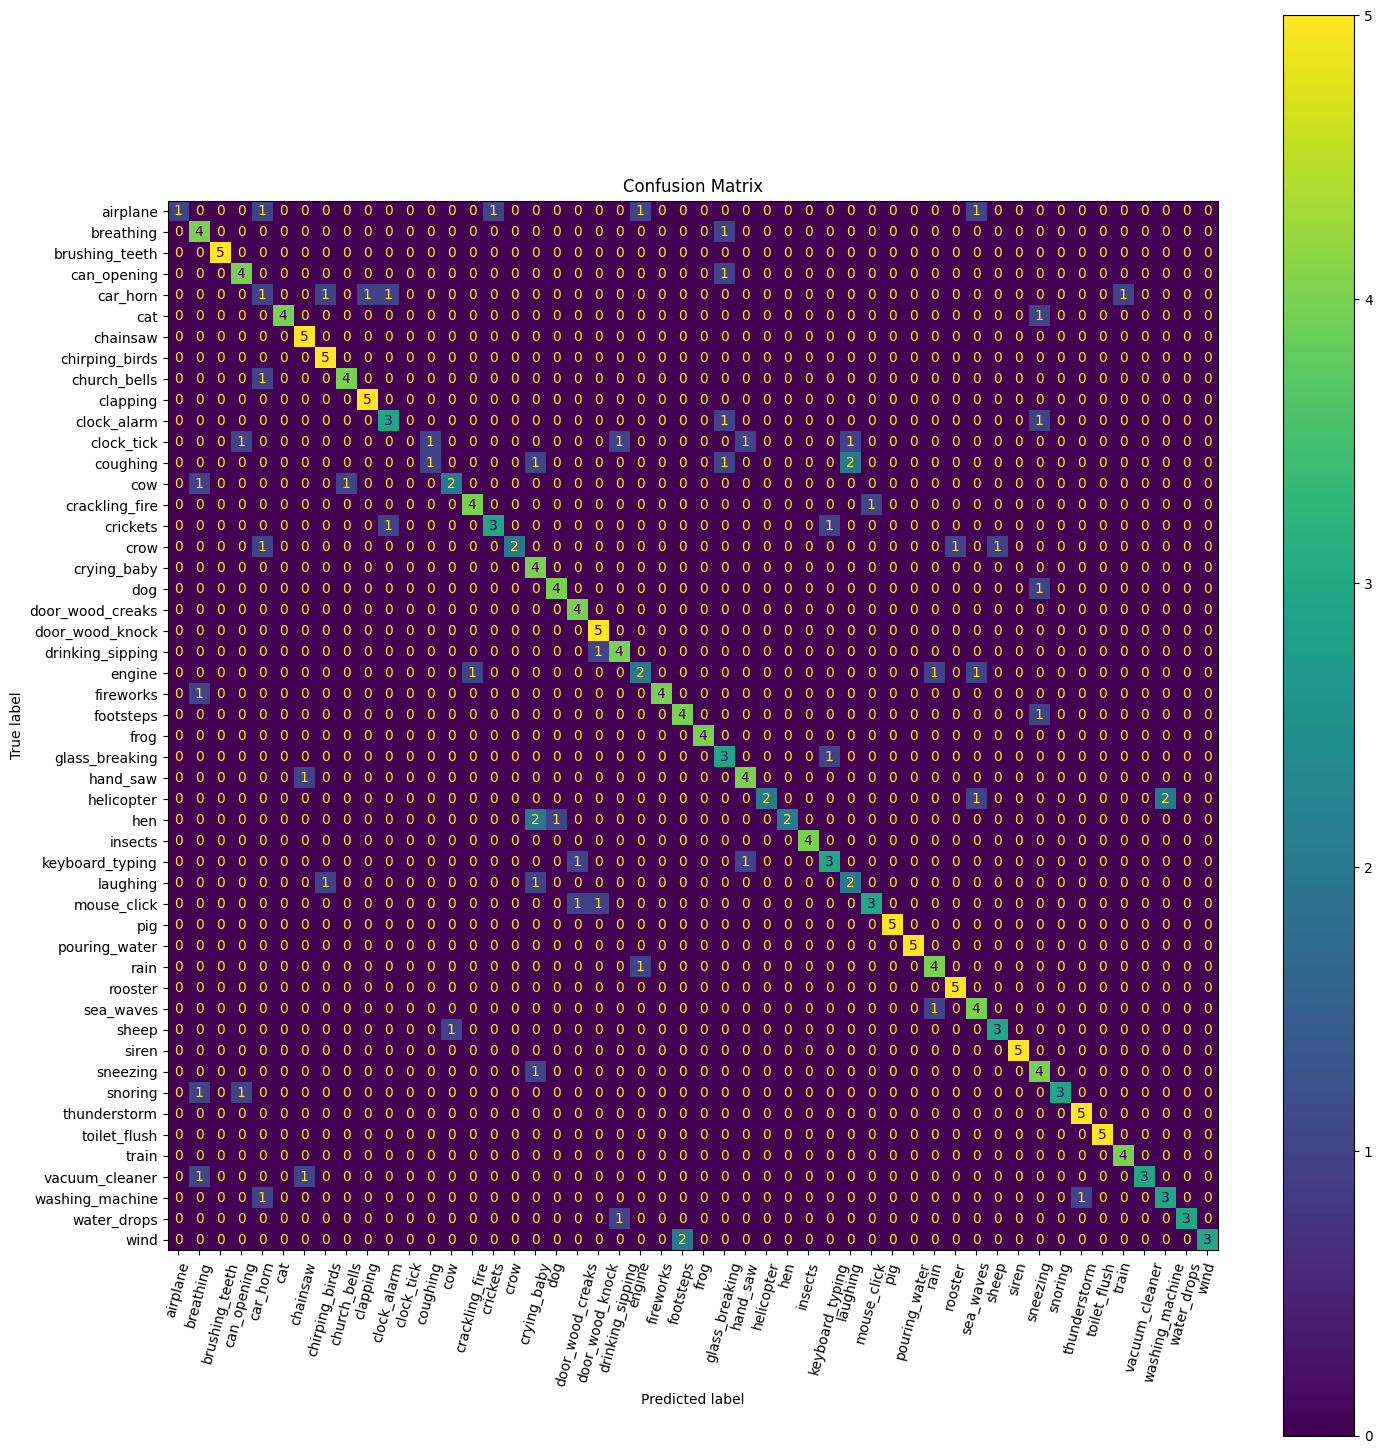

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_va, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(15, 15))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[idx_to_label[i] for i in range(len(classes))]
)

disp.plot(ax=ax, xticks_rotation=75)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Create a table of actual vs predicted labels
results = pd.DataFrame({
    'Actual': [idx_to_label[i] for i in y_va],
    'Predicted': [idx_to_label[i] for i in y_pred]
})

# Print mismatches by row
results = results[results['Actual'] == 'coughing']
results[results['Actual'] != results['Predicted']]

,Actual,Predicted
18,coughing,crying_baby
32,coughing,glass_breaking
53,coughing,laughing
106,coughing,laughing


# 🧪 (Optional) Training-time augmentation

If you want to improve robustness, add augmentation in feature extraction.

🟨 **STUDENT TODO:** Implement noise/bandpass/gain augmentation during training.

Tip: you can augment the waveform `y` before computing features.


In [ ]:
#@title 9) Load submission metadata

sub_meta = pd.read_csv(os.path.join(SUBMISSION_DIR, 'metadata.csv'))
sub_meta['clip_id'] = sub_meta['clip_id'].astype(str)
audio_sub_dir = os.path.join(SUBMISSION_DIR, 'audio')
print('Submission rows:', len(sub_meta))
sub_meta.head()


Submission rows: 1200


,clip_id
0,5-103415-A-2__clean
1,5-103416-A-2__clean
2,5-103418-A-2__clean
3,5-103420-A-2__clean
4,5-103421-A-2__clean


# ✅ Generate predictions.csv (THIS IS WHAT YOU SUBMIT)

This will run your feature extractor + model on every clip in `data/submission/audio`.

Make sure your output file name includes your team ID.


In [ ]:
#@title 10) Predict on submission set and write CSV
from google.colab import files

OUT_CSV = f'{GROUP_ID}_predictions.csv' # 🟨 STUDENT TODO: Ensure You have entered the correct ID earlier

pred_rows = []
for _, r in tqdm(sub_meta.iterrows(), total=len(sub_meta)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_sub_dir, f'{clip_id}.wav')
    feat = extract_features(wav_path)
    pred_idx = int(model.predict(feat.reshape(1, -1))[0])
    pred_label = idx_to_label[pred_idx]
    pred_rows.append((clip_id, pred_label))

out = pd.DataFrame(pred_rows, columns=['clip_id', 'predicted_label'])
out.to_csv(OUT_CSV, index=False)

print(f'Predictions saved to {OUT_CSV}. Downloading to your computer...')
files.download(OUT_CSV)

100%|██████████| 1200/1200 [01:55<00:00, 10.40it/s]

Predictions saved to Pr_18_predictions.csv. Downloading to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📤 How to submit
Upload to the model file (.joblib) and the predictions (.csv) to your xsite Dropbox.

**You only submit your model and prediction CSV and not the code.**
